In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import BernoulliNB,GaussianNB,MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score,accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
import seaborn as sns
from sklearn.model_selection import train_test_split
import joblib
from sklearn.base import BaseEstimator,TransformerMixin

# Step 1:  Loading Dataset

In [12]:
df = pd.read_csv('/content/drive/MyDrive/Bank_Loan_Classification/bank_loan_classification_dataset - bank_loan_classification_dataset.csv')
df.head()

,customer_id,age,gender,region,marital_status,education_level,employment_type,annual_income_lakh,credit_score,years_employed,existing_loans,debt_to_income_ratio,loan_amount_lakh,interest_rate_percent,missed_payments,savings_balance_lakh,loan_purpose,loan_approved
0,CUST000001,59,Male,North,Single,Bachelor,Business,9.25,721,7,4,37.83,7.67,13.35,4,7.26,Car,0
1,CUST000002,56,Male,North,Single,High School,Student,13.96,605,1,3,56.62,26.70,6.11,8,17.23,Home,0
2,CUST000003,47,Male,South,Married,Bachelor,Salaried,6.94,705,27,3,25.15,26.73,9.19,6,6.65,Personal,0
3,CUST000004,23,Male,West,Married,High School,Business,14.09,746,8,1,57.19,10.19,16.95,6,6.25,Car,0
4,CUST000005,28,Female,East,Single,Bachelor,Self-Employed,16.11,582,1,5,33.60,4.37,21.51,9,9.18,Education,0


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Step 2: explore dataset
- Dataset Shape
- Dataset Information
- Checking Missing Values


In [13]:
df.shape

(22000, 18)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            22000 non-null  object 
 1   age                    22000 non-null  int64  
 2   gender                 22000 non-null  object 
 3   region                 22000 non-null  object 
 4   marital_status         22000 non-null  object 
 5   education_level        22000 non-null  object 
 6   employment_type        22000 non-null  object 
 7   annual_income_lakh     22000 non-null  float64
 8   credit_score           22000 non-null  int64  
 9   years_employed         22000 non-null  int64  
 10  existing_loans         22000 non-null  int64  
 11  debt_to_income_ratio   22000 non-null  float64
 12  loan_amount_lakh       22000 non-null  float64
 13  interest_rate_percent  22000 non-null  float64
 14  missed_payments        22000 non-null  int64  
 15  sa

In [15]:
df.describe()

,age,annual_income_lakh,credit_score,years_employed,existing_loans,debt_to_income_ratio,loan_amount_lakh,interest_rate_percent,missed_payments,savings_balance_lakh,loan_approved
count,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000
mean,40.451864,12.037691,680.472136,17.052364,2.499318,32.557643,15.103424,14.011815,4.522864,8.176522,0.231591
std,11.548889,4.918078,80.114691,10.078260,1.716113,15.849679,7.715814,4.633025,2.868930,5.504690,0.421859
min,21.000000,2.000000,364.000000,0.000000,0.000000,5.000000,1.000000,6.000000,0.000000,0.000000,0.000000
25%,30.000000,8.640000,625.000000,8.000000,1.000000,18.877500,9.540000,9.970000,2.000000,3.890000,0.000000
50%,40.000000,12.000000,680.000000,17.000000,2.000000,32.545000,15.010000,14.030000,5.000000,7.930000,0.000000
75%,50.000000,15.370000,735.000000,26.000000,4.000000,46.232500,20.410000,18.060000,7.000000,11.930000,0.000000
max,60.000000,30.990000,900.000000,34.000000,5.000000,60.000000,48.180000,22.000000,9.000000,29.370000,1.000000


In [16]:
df.describe(include='object')

,customer_id,gender,region,marital_status,education_level,employment_type,loan_purpose
count,22000,22000,22000,22000,22000,22000,22000
unique,22000,2,4,2,4,4,5
top,CUST021984,Female,East,Single,High School,Student,Home
freq,1,11008,5537,11005,5557,5610,4482


In [17]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
region,0
marital_status,0
education_level,0
employment_type,0
annual_income_lakh,0
credit_score,0
years_employed,0


In [18]:
df.duplicated().sum()

np.int64(0)

# Step 3: Exploratory Data Analysis (EDA)
- Target Variable Distribution
- Correlation Heatmap
- Credit Score vs Loan Approval
- Outliers

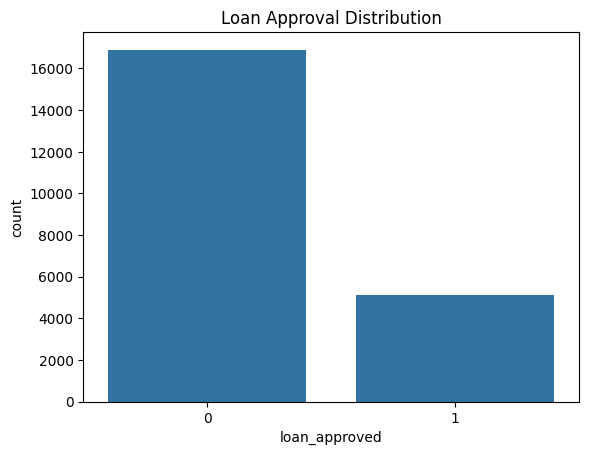

In [19]:
sns.countplot(data=df, x='loan_approved')
plt.title("Loan Approval Distribution")
plt.show()

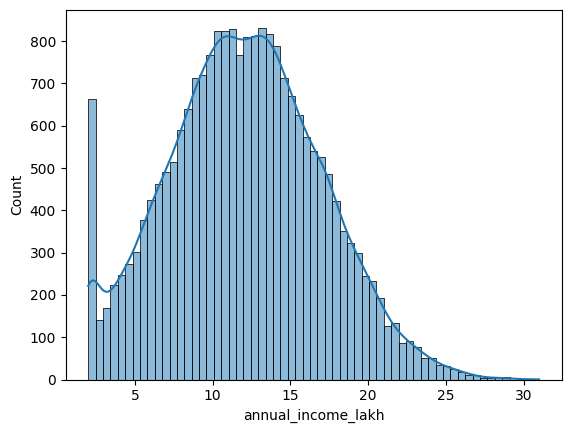

In [20]:
sns.histplot(df['annual_income_lakh'],kde=True)
plt.show()

In [21]:
df['education_level'].value_counts()

,count
education_level,
High School,5557
Master,5521
PhD,5487
Bachelor,5435


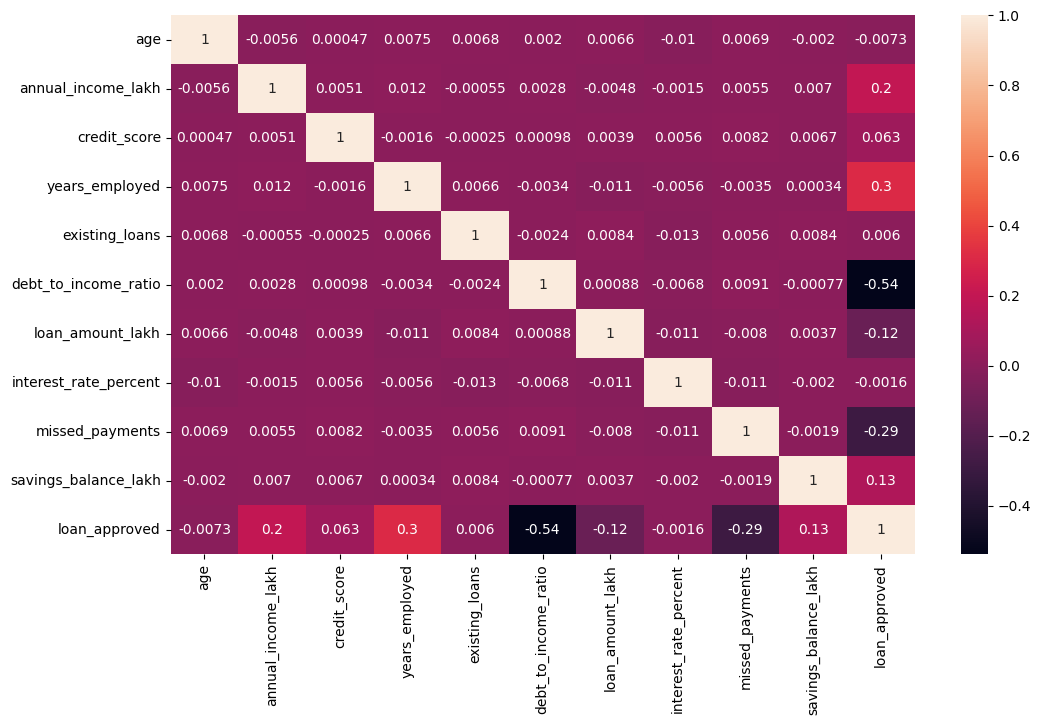

In [22]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(12,7))
sns.heatmap(correlation,annot=True)
plt.show()

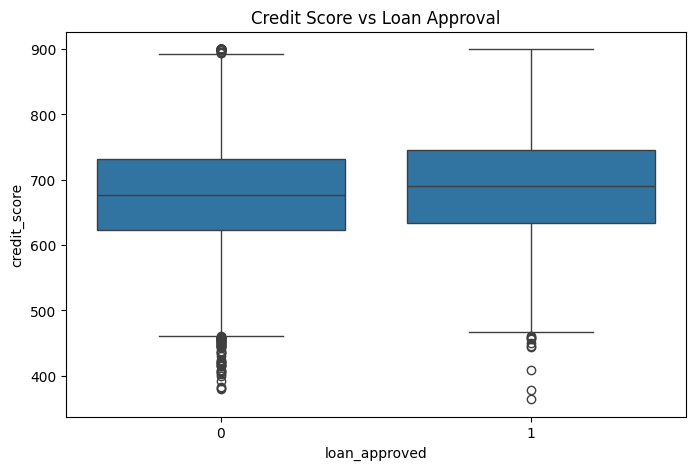

In [23]:
# Credit Score vs Loan Approval
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='loan_approved',
    y='credit_score'
)

plt.title("Credit Score vs Loan Approval")
plt.show()


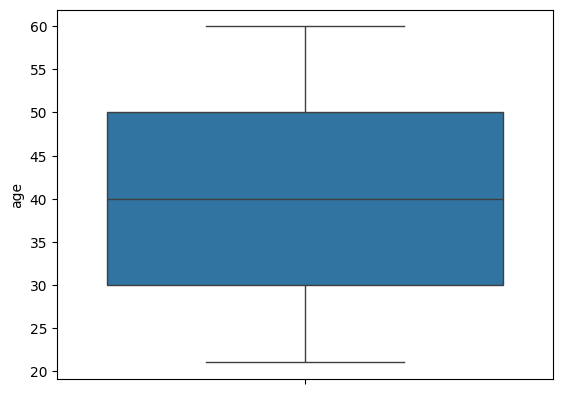

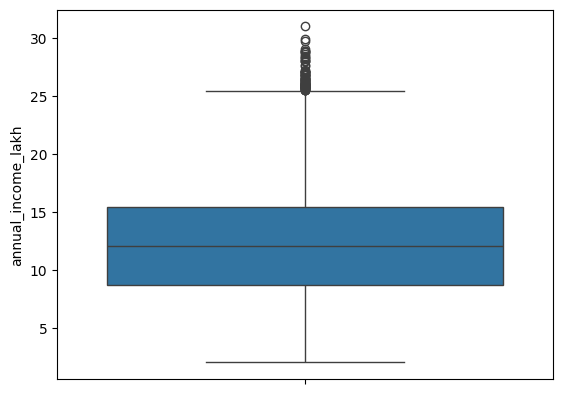

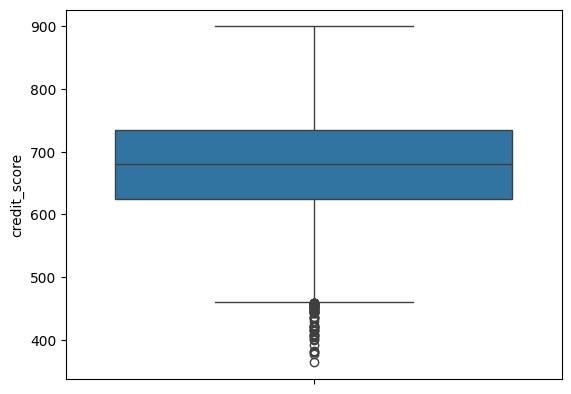

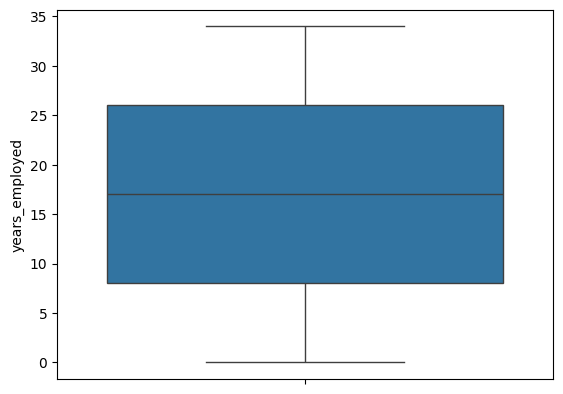

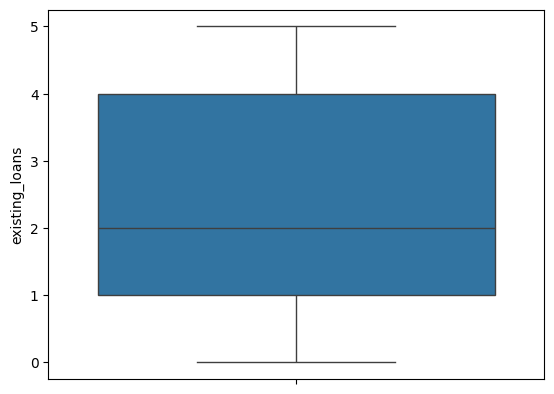

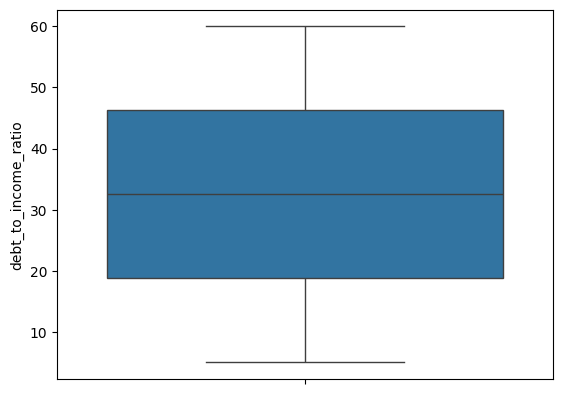

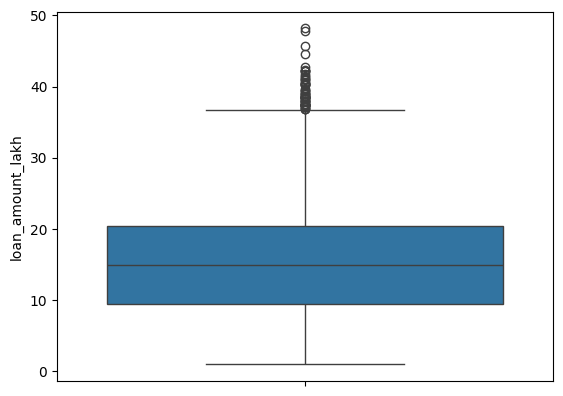

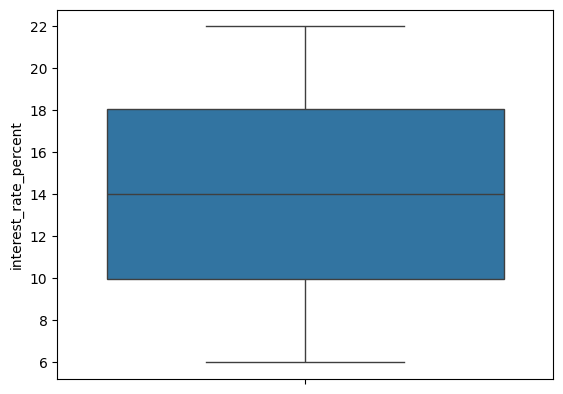

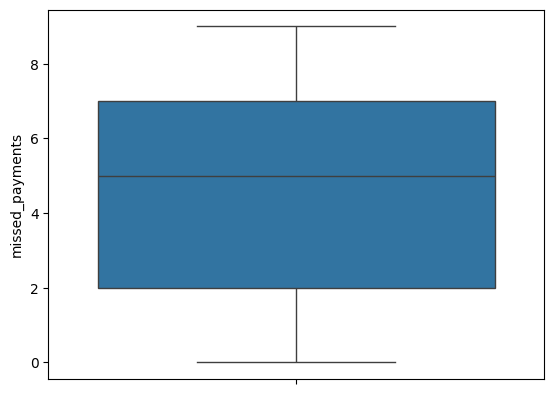

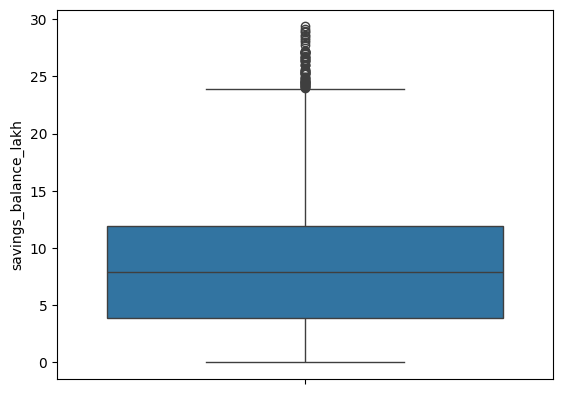

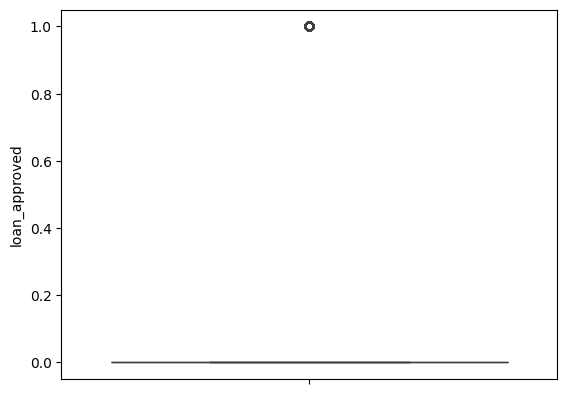

In [24]:
col=[x for x in df.columns if df[x].dtypes==int or df[x].dtypes==float]

for i in col:
  sns.boxplot(df[i])
  plt.show()

In [25]:
df_copy = df.copy()

In [26]:
cols = ["annual_income_lakh","credit_score","loan_amount_lakh"]

for i in cols:
  Q1 = df_copy[i].quantile(0.25)
  Q3 = df_copy[i].quantile(0.75)

  iqr = Q3 - Q1

  upperlimit = Q3 + (1.5 * iqr)
  lowerlimit = Q1 - (1.5 * iqr)

  df_copy = df_copy[ (df_copy[i] > lowerlimit) & (df_copy[i] < upperlimit)]

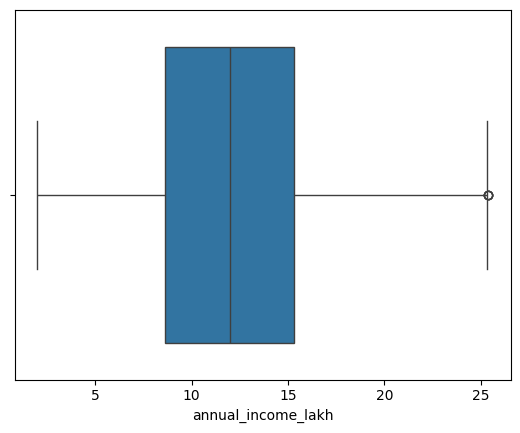

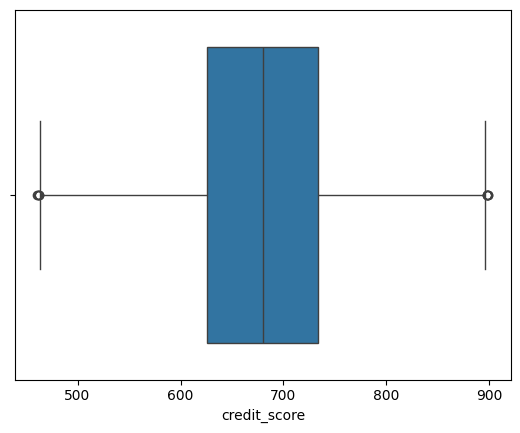

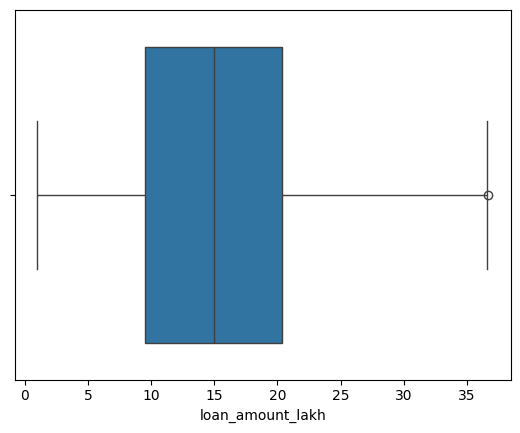

In [27]:
cols = ["annual_income_lakh","credit_score","loan_amount_lakh"]

for i in cols:
  sns.boxplot(x=df_copy[i])
  plt.show()

# Step 4: Feature Engineering
- Loan to Income Ratio
- Financial Stability Score
- Debt Burden Score

In [41]:
class FeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        # Loan Income Ratio
        X["loan_income_ratio"] = (
            X["loan_amount_lakh"]
            /
            (X["annual_income_lakh"] + 1)
        )

        # Financial Stability Score
        X["financial_stability_score"] = (
            (X["credit_score"] * 0.5)
            +
            (X["savings_balance_lakh"] * 10)
            -
            (X["missed_payments"] * 5)
        )

        # Debt Burden Score
        X["debt_burden_score"] = (
            X["debt_to_income_ratio"]
            *
            (X["existing_loans"] + 1)
        )

        return X

# Step 5 - Define Features and Target

- Features = Input variables

- Target = Variable we want to predict


In [29]:
x = df_copy.drop(axis=1,columns=['customer_id','region','loan_approved'])
y = df_copy['loan_approved']

# Step 6 - Data Preprocessing

We will:

## Numerical Features
- Fill missing values using median
- Apply Standard Scaling

## Categorical Features
- Fill missing values using most frequent
- Apply Ordinal Encoding


In [30]:
numerical_feature = x.select_dtypes(exclude="object").columns
ordinal_feature = ["education_level"]
categorical_feature = ["gender","marital_status","employment_type","loan_purpose"]

# Step 7 - creating preprocessing pipeline

We will:
- Encode categorical data
- Scale numerical data


In [31]:
numeric_tranformer = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('StandardScaler',MinMaxScaler())
    ]
)

categoricalOD_transformer = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('Ordinal',OrdinalEncoder(categories=[['High School','Bachelor','Master','PhD']]))
    ]
)

categoricalLE_transformer = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('Label',OrdinalEncoder())
    ]
)

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',numeric_tranformer,numerical_feature),
        ('categoricalOD',categoricalOD_transformer,ordinal_feature),
        ('categoricalLE',categoricalLE_transformer,categorical_feature)
    ]
)

# Step 8 - Train-Test Split

In [33]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.75,random_state=42)

# Logistic Regression

In [42]:
logistic_model = Pipeline(
    steps=[
        ("feature_engineering", FeatureEngineer()),
        ('preprocessing',preprocessor),
        ('model',LogisticRegression())
    ]
)


# Bernoulli Naive Bayes

In [43]:
BernoulliNB_model = Pipeline(
    steps=[
        ("feature_engineering", FeatureEngineer()),
        ('preprocessing',preprocessor),
        ('model',BernoulliNB())
    ]
)

# Gaussian Naive Bayes

In [44]:
GaussianNB_model = Pipeline(
    steps=[
        ("feature_engineering", FeatureEngineer()),
        ('preprocessing',preprocessor),
        ('model',GaussianNB())
    ]
)

# Multinomial Naive Bayes

In [45]:
MultinomialNB_model = Pipeline(
    steps=[
        ("feature_engineering", FeatureEngineer()),
        ('preprocessing',preprocessor),
        ('model',MultinomialNB())
    ]
)

# KNeighborsClassifier

In [46]:
KNeighborsClassifier_model = Pipeline(
    steps=[
        ("feature_engineering", FeatureEngineer()),
        ('preprocessing',preprocessor),
        ('model',KNeighborsClassifier(n_neighbors=3))
    ]
)

In [39]:
models = {
    'logistic':logistic_model,
    'knn':KNeighborsClassifier_model,
    'bernoli':BernoulliNB_model,
    'Gausian':GaussianNB_model,
    'multi':MultinomialNB_model
}

for name , model in models.items():
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)

  print(f'{name}')
  print("*********************")
  print('Metric Evaluation')

  print('accuracy_score',accuracy_score(y_test,y_pred))
  print('f1_score',f1_score(y_test,y_pred,zero_division=0))
  print('confusion_matrix',confusion_matrix(y_test,y_pred))
  print('precision_score',precision_score(y_test,y_pred,zero_division=0))
  print('recall_score',recall_score(y_test,y_pred,zero_division=0))

  print('\n')


logistic
*********************
Metric Evaluation
accuracy_score 0.9900607399226946
f1_score 0.9790859798605732
confusion_matrix [[4115   11]
 [  43 1264]]
precision_score 0.9913725490196078
recall_score 0.9671002295332823


knn
*********************
Metric Evaluation
accuracy_score 0.8286397938523836
f1_score 0.572347266881029
confusion_matrix [[3879  247]
 [ 684  623]]
precision_score 0.7160919540229885
recall_score 0.47666411629686306


bernoli
*********************
Metric Evaluation
accuracy_score 0.7610896374010675
f1_score 0.025525525525525526
confusion_matrix [[4118    8]
 [1290   17]]
precision_score 0.68
recall_score 0.013006885998469778


Gausian
*********************
Metric Evaluation
accuracy_score 0.9123872630222714
f1_score 0.8291457286432161
confusion_matrix [[3802  324]
 [ 152 1155]]
precision_score 0.7809330628803245
recall_score 0.8837031369548585


multi
*********************
Metric Evaluation
accuracy_score 0.75943309405485
f1_score 0.0
confusion_matrix [[4126    0]


In [47]:
logistic_model.fit(x_train,y_train)

Pipeline(steps=[('feature_engineering', FeatureEngineer()),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('StandardScaler',
                                                                   MinMaxScaler())]),
                                                  Index(['age', 'annual_income_lakh', 'credit_score', 'years_employed',
       'existing_loans', 'debt_to_income_ratio', 'loan_amount_lakh',
       'interest_rate...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Ordinal',
                                                                   OrdinalEncoder(categories=[['High '
                                                                                               'School',
                                                                                               'Bachelor',
                                                                                               'Master',
                                                                                               'PhD']]))]),
                                                  ['education_level']),
                                                 ('categoricalLE',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Label',
                                                                   OrdinalEncoder())]),
                                                  ['gender', 'marital_status',
                                                   'employment_type',
                                                   'loan_purpose'])])),
                ('model', LogisticRegression())])

In [48]:
joblib.dump(logistic_model,"/content/drive/MyDrive/Bank_Loan_Classification/model_new.pkl")

['/content/drive/MyDrive/Bank_Loan_Classification/model_new.pkl']

In [49]:
import sklearn
print(sklearn.__version__)

1.6.1
